## Preparación del entorno

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)


import warnings
warnings.filterwarnings("ignore")

PALETA = ["#E8505B", "#5B7CFA", "#19A974", "#F4A259", "#8E5BA6", "#00A6A6"]
GRIS = "#9AA0C0"
plt.rcParams.update({
    "figure.figsize": (6, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
pd.set_option("display.width", 130)

def dibuja(X, labels=None, titulo="", ax=None, xlabel="x1", ylabel="x2"):
    if ax is None:
        _, ax = plt.subplots()
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=26, c=GRIS, edgecolor="white", linewidth=0.5)
    else:
        for i, lab in enumerate(sorted(set(labels))):
            m = labels == lab
            color = GRIS if lab == -1 else PALETA[i % len(PALETA)]
            nombre = "ruido (-1)" if lab == -1 else f"grupo {lab}"
            ax.scatter(X[m, 0], X[m, 1], s=26, c=color, label=nombre,
                       edgecolor="white", linewidth=0.5)
        ax.legend(fontsize=8, frameon=False)
    ax.set_title(titulo, fontsize=11, weight="bold")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    return ax

print("Entorno listo.")

Entorno listo.


---
# Bloque 1 · Cargar, explorar y preparar

## Ejercicio 1 — Cargar iris y describirlo

In [18]:
iris = load_iris(as_frame=True)
X = iris.data
especies = iris.target
nombres_esp = iris.target_names

print("a) Primeras filas:")
print(X.head().to_string())

print("\nb) Dimensiones:", X.shape)
print("   Valores nulos por columna:")
print(X.isna().sum().to_string())

print("\nc) Estadísticos descriptivos:")
print(X.describe().round(2).to_string())

rangos = pd.DataFrame({"mínimo": X.min(), "máximo": X.max(), "rango": X.max() - X.min()})
print("\n   Rango de cada variable:")
print(rangos.round(2).to_string())

print("\nd) Flores por especie:")
print(pd.Series(especies).map(dict(enumerate(nombres_esp))).value_counts().to_string())

a) Primeras filas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

b) Dimensiones: (150, 4)
   Valores nulos por columna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0

c) Estadísticos descriptivos:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count             150.00            150.00             150.00            150.00
mean                5.84              3.06               3.76              1.20
std                 0.83              0.44               1.77              0.76
min                 4.30  

## Ejercicio 2 — Explorar visualmente


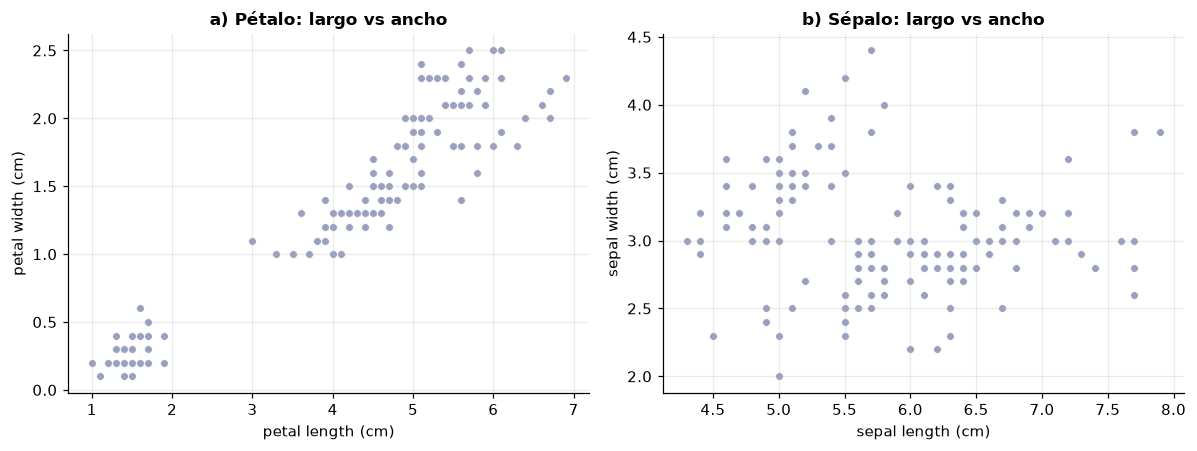

In [19]:
cols = list(X.columns)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
dibuja(X[[cols[2], cols[3]]].values, titulo="a) Pétalo: largo vs ancho", ax=ax1,
       xlabel=cols[2], ylabel=cols[3])
dibuja(X[[cols[0], cols[1]]].values, titulo="b) Sépalo: largo vs ancho", ax=ax2,
       xlabel=cols[0], ylabel=cols[1])
plt.tight_layout(); plt.show()

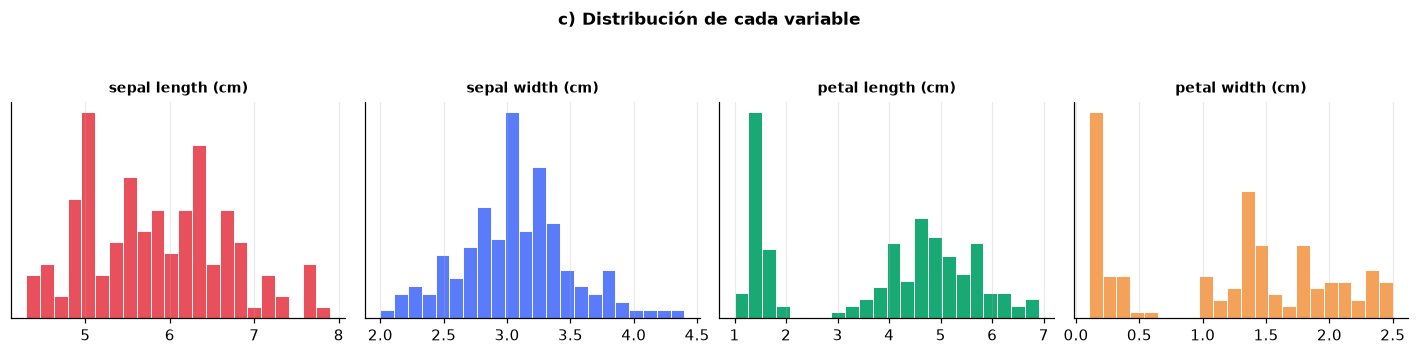

Matriz de correlación:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)               1.00             -0.12               0.87              0.82
sepal width (cm)               -0.12              1.00              -0.43             -0.37
petal length (cm)               0.87             -0.43               1.00              0.96
petal width (cm)                0.82             -0.37               0.96              1.00


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, col, color in zip(axes, cols, PALETA):
    ax.hist(X[col], bins=22, color=color, edgecolor="white", linewidth=0.6)
    ax.set_title(col, fontsize=9, weight="bold")
    ax.set_yticks([])
plt.suptitle("c) Distribución de cada variable", fontsize=11, weight="bold", y=1.06)
plt.tight_layout(); plt.show()

print("Matriz de correlación:")
print(X.corr().round(2).to_string())

## Ejercicio 3 — Escalar las variables

In [21]:
escalador = StandardScaler()
X_esc = escalador.fit_transform(X)

print("b) Comprobación del escalado")
print("   Media por columna :", np.round(X_esc.mean(axis=0), 6))
print("   Desv. estándar    :", np.round(X_esc.std(axis=0), 6))

comparacion = pd.DataFrame({
    "rango original": (X.max() - X.min()).values,
    "desv. original": X.std().values,
    "rango escalado": X_esc.max(axis=0) - X_esc.min(axis=0),
    "desv. escalada": X_esc.std(axis=0),
}, index=cols)
print("\nc) Rangos antes y después de escalar:")
print(comparacion.round(2).to_string())

print("\n   Razón entre el rango mayor y el menor:")
print("   antes de escalar : %.2f" % ((X.max() - X.min()).max() / (X.max() - X.min()).min()))
print("   después de escalar: %.2f" % ((X_esc.max(0) - X_esc.min(0)).max() /
                                       (X_esc.max(0) - X_esc.min(0)).min()))

b) Comprobación del escalado
   Media por columna : [-0. -0. -0. -0.]
   Desv. estándar    : [1. 1. 1. 1.]

c) Rangos antes y después de escalar:
                   rango original  desv. original  rango escalado  desv. escalada
sepal length (cm)             3.6            0.83            4.36             1.0
sepal width (cm)              2.4            0.44            5.52             1.0
petal length (cm)             5.9            1.77            3.35             1.0
petal width (cm)              2.4            0.76            3.16             1.0

   Razón entre el rango mayor y el menor:
   antes de escalar : 2.46
   después de escalar: 1.75


## Ejercicio 4 — Reducir a dos dimensiones con PCA

a) Varianza explicada por componente:
   PC1:  73.0%   (acumulado:  73.0%)
   PC2:  22.9%   (acumulado:  95.8%)
   PC3:   3.7%   (acumulado:  99.5%)
   PC4:   0.5%   (acumulado: 100.0%)

b) Las dos primeras componentes explican el 95.8% de la varianza total.


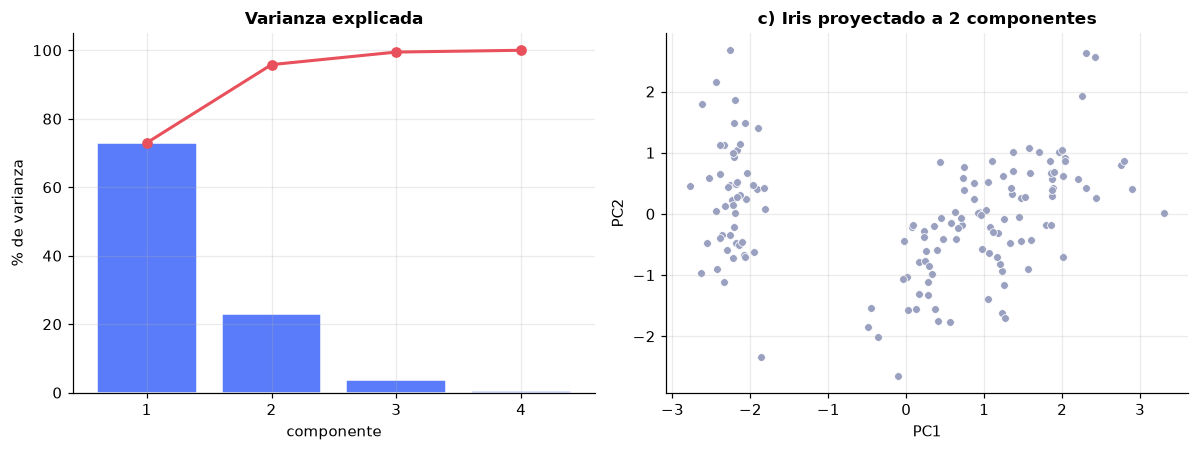

In [22]:
pca_full = PCA().fit(X_esc)
var = pca_full.explained_variance_ratio_

print("a) Varianza explicada por componente:")
for i, v in enumerate(var, 1):
    print(f"   PC{i}: {v:6.1%}   (acumulado: {var[:i].sum():6.1%})")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_esc)
print("\nb) Las dos primeras componentes explican el %.1f%% de la varianza total." % (var[:2].sum() * 100))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(range(1, 5), var * 100, color=PALETA[1], edgecolor="white")
ax1.plot(range(1, 5), np.cumsum(var) * 100, "o-", color=PALETA[0], linewidth=2)
ax1.set_title("Varianza explicada", fontsize=11, weight="bold")
ax1.set_xlabel("componente"); ax1.set_ylabel("% de varianza")
ax1.set_xticks(range(1, 5))

dibuja(X_pca, titulo="c) Iris proyectado a 2 componentes", ax=ax2, xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()

---
# Bloque 2 · K-Means

## Ejercicio 5 — Entrenar K-Means con k = 3


In [23]:
km = KMeans(n_clusters=3, n_init=10, random_state=42)
grupos_km = km.fit_predict(X_esc)

print("a) y b) Resultados del modelo")
print("   Inercia final       : %.2f" % km.inertia_)
print("   Iteraciones          :", km.n_iter_)
print("   Flores por grupo     :", np.bincount(grupos_km))
print("   Silueta              : %.3f" % silhouette_score(X_esc, grupos_km))

print("\nc) Centroides devueltos a CENTÍMETROS:")
centros_cm = pd.DataFrame(escalador.inverse_transform(km.cluster_centers_), columns=cols)
centros_cm.index.name = "grupo"
print(centros_cm.round(2).to_string())

a) y b) Resultados del modelo
   Inercia final       : 139.82
   Iteraciones          : 4
   Flores por grupo     : [53 50 47]
   Silueta              : 0.460

c) Centroides devueltos a CENTÍMETROS:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
grupo                                                                          
0                   5.80              2.67               4.37              1.41
1                   5.01              3.43               1.46              0.25
2                   6.78              3.10               5.51              1.97


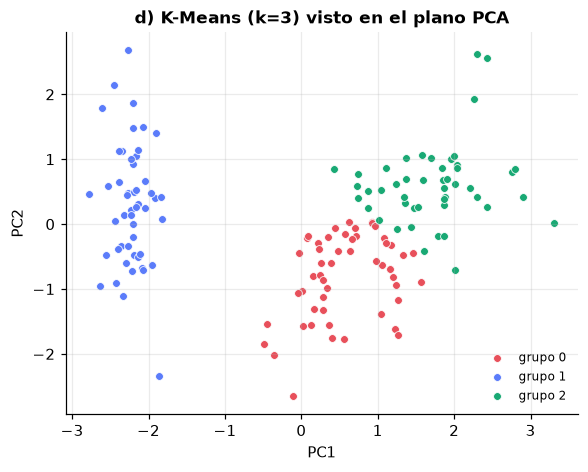

In [24]:
dibuja(X_pca, grupos_km, titulo="d) K-Means (k=3) visto en el plano PCA",
       xlabel="PC1", ylabel="PC2")
plt.show()

## Ejercicio 6 — Elegir el número de grupos


In [25]:
ks = range(1, 11)
inercias, siluetas = [], []
for k in ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_esc)
    inercias.append(m.inertia_)
    siluetas.append(np.nan if k == 1 else silhouette_score(X_esc, m.labels_))

tabla = pd.DataFrame({"k": list(ks), "inercia": np.round(inercias, 1),
                      "silueta": np.round(siluetas, 3)})
tabla["reducción_%"] = (-tabla["inercia"].pct_change() * 100).round(1)
print(tabla.to_string(index=False))

print("\nk que maximiza la silueta:", int(np.nanargmax(siluetas)) + 1)

 k  inercia  silueta  reducción_%
 1    600.0      NaN          NaN
 2    222.4    0.582         62.9
 3    139.8    0.460         37.1
 4    114.1    0.387         18.4
 5     90.9    0.346         20.3
 6     81.5    0.317         10.3
 7     72.6    0.320         10.9
 8     62.5    0.339         13.9
 9     55.1    0.342         11.8
10     47.4    0.352         14.0

k que maximiza la silueta: 2


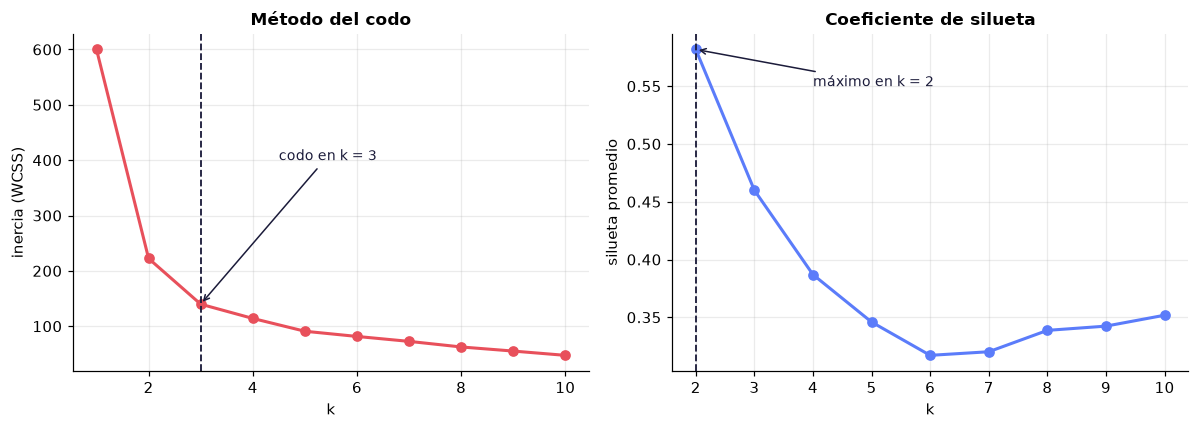

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(list(ks), inercias, "o-", color=PALETA[0], linewidth=2, markersize=6)
ax1.axvline(3, color="#1B1B3A", linestyle="--", linewidth=1.2)
ax1.annotate("codo en k = 3", xy=(3, inercias[2]), xytext=(4.5, 400),
             fontsize=9, color="#1B1B3A",
             arrowprops=dict(arrowstyle="->", color="#1B1B3A", lw=1))
ax1.set_title("Método del codo", fontsize=11, weight="bold")
ax1.set_xlabel("k"); ax1.set_ylabel("inercia (WCSS)")

ax2.plot(list(ks)[1:], siluetas[1:], "o-", color=PALETA[1], linewidth=2, markersize=6)
ax2.axvline(2, color="#1B1B3A", linestyle="--", linewidth=1.2)
ax2.annotate("máximo en k = 2", xy=(2, siluetas[1]), xytext=(4, 0.55),
             fontsize=9, color="#1B1B3A",
             arrowprops=dict(arrowstyle="->", color="#1B1B3A", lw=1))
ax2.set_title("Coeficiente de silueta", fontsize=11, weight="bold")
ax2.set_xlabel("k"); ax2.set_ylabel("silueta promedio")

plt.tight_layout(); plt.show()

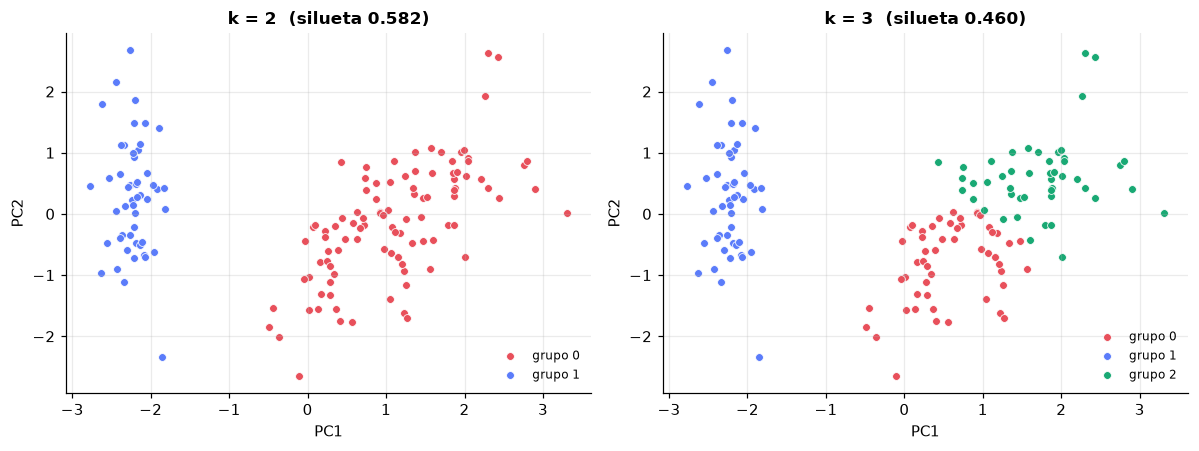

In [27]:
# Ver las dos particiones candidatas, una al lado de la otra
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for k, ax in [(2, ax1), (3, ax2)]:
    lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_esc)
    dibuja(X_pca, lab, titulo=f"k = {k}  (silueta {silhouette_score(X_esc, lab):.3f})",
           ax=ax, xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()

## Ejercicio 7 — Comparar los grupos con las especies reales


In [28]:
etiquetas_esp = pd.Series(especies).map(dict(enumerate(nombres_esp)))

print("a) Tabla de contingencia: grupos de K-Means vs especies reales\n")
tc = pd.crosstab(pd.Series(grupos_km, name="grupo K-Means"), etiquetas_esp)
print(tc.to_string())

print("\nb) Métricas de validación")
print("   ARI : %.3f" % adjusted_rand_score(especies, grupos_km))
print("   NMI : %.3f" % normalized_mutual_info_score(especies, grupos_km))

print("\nc) Diagnóstico por especie")
for esp in nombres_esp:
    col = tc[esp]
    print(f"   {esp:<12}: repartida en {(col > 0).sum()} grupo(s) -> {dict(col[col > 0])}")
mal = int(tc.values.sum() - tc.max(axis=1).sum())
print(f"\n   Flores en el grupo 'equivocado' (tomando la especie mayoritaria de cada grupo): {mal}")

a) Tabla de contingencia: grupos de K-Means vs especies reales

target         setosa  versicolor  virginica
grupo K-Means                               
0                   0          39         14
1                  50           0          0
2                   0          11         36

b) Métricas de validación
   ARI : 0.620
   NMI : 0.659

c) Diagnóstico por especie
   setosa      : repartida en 1 grupo(s) -> {1: np.int64(50)}
   versicolor  : repartida en 2 grupo(s) -> {0: np.int64(39), 2: np.int64(11)}
   virginica   : repartida en 2 grupo(s) -> {0: np.int64(14), 2: np.int64(36)}

   Flores en el grupo 'equivocado' (tomando la especie mayoritaria de cada grupo): 25


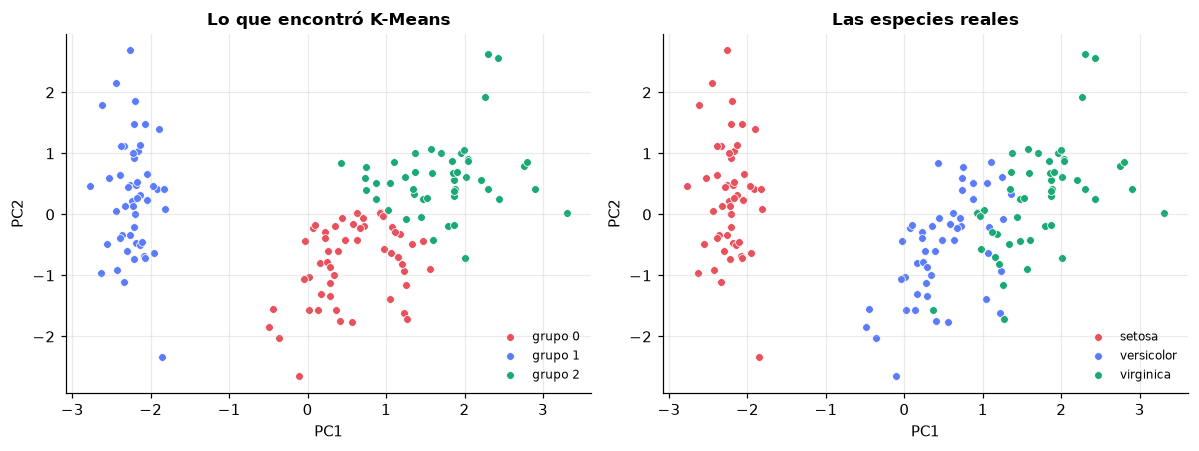

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
dibuja(X_pca, grupos_km, titulo="Lo que encontró K-Means", ax=ax1, xlabel="PC1", ylabel="PC2")
for i, esp in enumerate(nombres_esp):
    m = especies == i
    ax2.scatter(X_pca[m, 0], X_pca[m, 1], s=26, c=PALETA[i], label=esp,
                edgecolor="white", linewidth=0.5)
ax2.legend(fontsize=8, frameon=False)
ax2.set_title("Las especies reales", fontsize=11, weight="bold")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
plt.tight_layout(); plt.show()

## Ejercicio 8 — ¿Escalar siempre mejora? Un experimento


In [30]:
km_sin = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X.values)
km_con = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_esc)

resultado = pd.DataFrame([
    {"modelo": "SIN escalar", "ARI": adjusted_rand_score(especies, km_sin.labels_),
     "NMI": normalized_mutual_info_score(especies, km_sin.labels_),
     "silueta": silhouette_score(X.values, km_sin.labels_),
     "tamaños": str(np.bincount(km_sin.labels_))},
    {"modelo": "CON escalar", "ARI": adjusted_rand_score(especies, km_con.labels_),
     "NMI": normalized_mutual_info_score(especies, km_con.labels_),
     "silueta": silhouette_score(X_esc, km_con.labels_),
     "tamaños": str(np.bincount(km_con.labels_))},
]).set_index("modelo")
print("a) y b) Comparación\n")
print(resultado.round(3).to_string())

a) y b) Comparación

              ARI    NMI  silueta     tamaños
modelo                                       
SIN escalar  0.73  0.758    0.553  [62 50 38]
CON escalar  0.62  0.659    0.460  [53 50 47]


In [31]:
print("c) ¿Qué variable pesa más en cada caso?\n")
diag = pd.DataFrame({
    "desv. estándar original": X.std().values,
    "peso relativo SIN escalar": (X.var().values / X.var().sum()).round(3),
    "peso relativo CON escalar": np.repeat(0.25, 4),
}, index=cols)
print(diag.round(3).to_string())

print("\nCapacidad de cada variable para separar las especies (ratio F de ANOVA):")
from sklearn.feature_selection import f_classif
f_vals, _ = f_classif(X, especies)
print(pd.Series(f_vals, index=cols).sort_values(ascending=False).round(1).to_string())

c) ¿Qué variable pesa más en cada caso?

                   desv. estándar original  peso relativo SIN escalar  peso relativo CON escalar
sepal length (cm)                    0.828                      0.150                       0.25
sepal width (cm)                     0.436                      0.042                       0.25
petal length (cm)                    1.765                      0.681                       0.25
petal width (cm)                     0.762                      0.127                       0.25

Capacidad de cada variable para separar las especies (ratio F de ANOVA):
petal length (cm)    1180.2
petal width (cm)      960.0
sepal length (cm)     119.3
sepal width (cm)       49.2


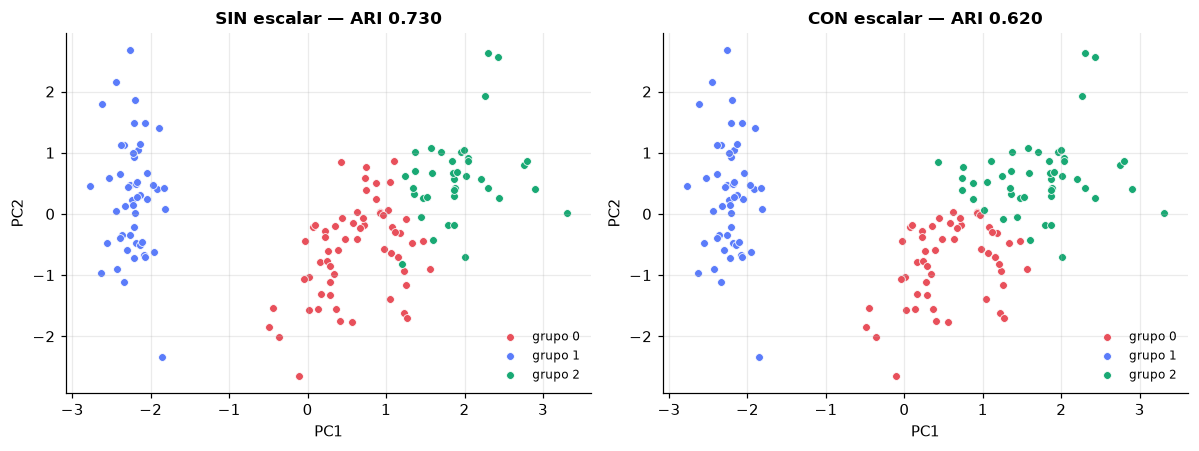

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
dibuja(X_pca, km_sin.labels_,
       titulo=f"SIN escalar — ARI {adjusted_rand_score(especies, km_sin.labels_):.3f}",
       ax=ax1, xlabel="PC1", ylabel="PC2")
dibuja(X_pca, km_con.labels_,
       titulo=f"CON escalar — ARI {adjusted_rand_score(especies, km_con.labels_):.3f}",
       ax=ax2, xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()